In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import torch
from torch.utils.data import DataLoader

from dataset import SceneTwoPairsDataset
from model import PairImageCylinderModel
from losses import consistency_loss, consistency_loss_fast


In [3]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

CUDA available: True
NVIDIA GeForce RTX 5050 Laptop GPU


In [4]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = PairImageCylinderModel(
    img_size=128,
    patch_size=16,
    embed_dim=256,
    depth=4,
    num_heads=4,
    num_cylinders=5,
).to(device)

In [5]:
dataset = SceneTwoPairsDataset(
    root_dir="dataset",
    image_size=128,
    pairs_per_scene=20,
    return_paths=False,
)

loader = DataLoader(
    dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0,
)

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

model.train()
for epoch in range(5):
    total_loss = 0.0

    for batch in loader:
        img_a1, img_b1, img_a2, img_b2 = batch

        img_a1 = img_a1.to(device, non_blocking=True)
        img_b1 = img_b1.to(device, non_blocking=True)
        img_a2 = img_a2.to(device, non_blocking=True)
        img_b2 = img_b2.to(device, non_blocking=True)

        pred1 = model(img_a1, img_b1)
        pred2 = model(img_a2, img_b2)

        # loss = consistency_loss(pred1, pred2)
        loss = consistency_loss_fast(pred1, pred2, lambda_conf_reg=0.01)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}: loss={total_loss / len(loader):.4f}")
    print("pred1 mean/std:", pred1.mean().item(), pred1.std().item())
    print("pred2 mean/std:", pred2.mean().item(), pred2.std().item())

Epoch 1: loss=0.0096
pred1 mean/std: 0.2851806879043579 0.3258146345615387
pred2 mean/std: 0.2854270339012146 0.3256688416004181
Epoch 2: loss=0.0042
pred1 mean/std: 0.2706596255302429 0.35047250986099243
pred2 mean/std: 0.27028289437294006 0.3501279950141907
Epoch 3: loss=0.0024
pred1 mean/std: 0.2558639347553253 0.40663453936576843
pred2 mean/std: 0.2560647428035736 0.40686601400375366
Epoch 4: loss=0.0013
pred1 mean/std: 0.25149840116500854 0.4615265429019928
pred2 mean/std: 0.2519536018371582 0.4614717960357666
Epoch 5: loss=0.0007
pred1 mean/std: 0.25237223505973816 0.49920883774757385
pred2 mean/std: 0.25239190459251404 0.498818039894104


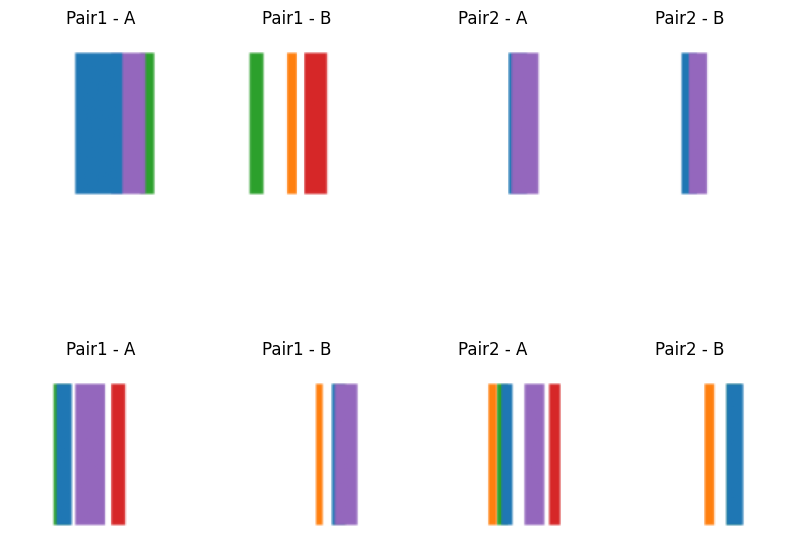

Pred1 shape: torch.Size([8, 5, 5])
Pred2 shape: torch.Size([8, 5, 5])

Exempel cylinder (pair1): tensor([ 0.6139, -0.8803, -0.8532,  0.6406,  0.0280], device='cuda:0')
Exempel cylinder (pair2): tensor([ 0.6130, -0.8798, -0.8518,  0.6432,  0.0282], device='cuda:0')
Confidence (pair1): tensor([0.0280, 0.0422, 0.0261, 0.0289, 0.0422], device='cuda:0')


In [8]:
# Cell: sanity check för två bildpar

import matplotlib.pyplot as plt

def show_two_pairs(img_a1, img_b1, img_a2, img_b2, max_items=2):
    img_a1 = img_a1.cpu()
    img_b1 = img_b1.cpu()
    img_a2 = img_a2.cpu()
    img_b2 = img_b2.cpu()

    n = min(img_a1.shape[0], max_items)

    plt.figure(figsize=(8, 4 * n))

    for i in range(n):
        # Första paret
        plt.subplot(n, 4, 4*i + 1)
        plt.imshow(img_a1[i].permute(1, 2, 0))
        plt.title("Pair1 - A")
        plt.axis("off")

        plt.subplot(n, 4, 4*i + 2)
        plt.imshow(img_b1[i].permute(1, 2, 0))
        plt.title("Pair1 - B")
        plt.axis("off")

        # Andra paret
        plt.subplot(n, 4, 4*i + 3)
        plt.imshow(img_a2[i].permute(1, 2, 0))
        plt.title("Pair2 - A")
        plt.axis("off")

        plt.subplot(n, 4, 4*i + 4)
        plt.imshow(img_b2[i].permute(1, 2, 0))
        plt.title("Pair2 - B")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


# Hämta batch
batch = next(iter(loader))
img_a1, img_b1, img_a2, img_b2 = batch

# Visa bilder
show_two_pairs(img_a1, img_b1, img_a2, img_b2)

# Skicka till device
img_a1 = img_a1.to(device)
img_b1 = img_b1.to(device)
img_a2 = img_a2.to(device)
img_b2 = img_b2.to(device)

# Kör modellen
with torch.no_grad():
    pred1 = model(img_a1, img_b1)
    pred2 = model(img_a2, img_b2)

print("Pred1 shape:", pred1.shape)  # [B, K, 5]
print("Pred2 shape:", pred2.shape)

print("\nExempel cylinder (pair1):", pred1[0, 0])
print("Exempel cylinder (pair2):", pred2[0, 0])
print("Confidence (pair1):", pred1[0, :, 4])